In [2]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph  # framework that helps you design and manage the flow of tasks in your application using a graph


/Users/kapil/Projects/lang_graph/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kapil/Projects/lang_graph/.venv/lib/python3.9/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict):
    message: str


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] = "Hey " + state["message"] + ", how is your day going?\n"

    return state

def farewell_node(state: AgentState) -> AgentState:
    """Final node that adds a goodbye message to the state"""

    state['message'] = state['message'] + " Have a great day, bye!"

    return state

In [4]:
state = AgentState(message="Sonny")

print("greeting node:", greeting_node(state))  # Output: Initial state: {'message': 'Hey Kapil, how is your day going?'}

greeting node: {'message': 'Hey Sonny, how is your day going?\n'}


In [5]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)
graph.add_node("farewell", farewell_node)

graph.set_entry_point("greeter")
graph.add_edge("greeter", "farewell")
graph.set_finish_point("farewell")

app = graph.compile()

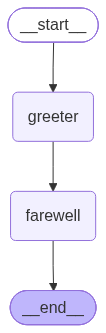

Hey Kapil, how is your day going?
 Have a great day, bye!


In [6]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

result = app.invoke({"message": "Kapil"})
print(result['message'])